In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Connect to ml directory
ml_root = Path().resolve().parents[0]
sys.path.append(str(ml_root))

# Load the dataset
data_path = ml_root / "data" / "processed" / "train_FD001_features.csv"
train_features = pd.read_csv(data_path)

print("=" * 60)
print(f"Dataset Loaded Successfully: {train_features.shape}")

Dataset Loaded Successfully: (20631, 48)


In [2]:
feature_cols = [c for c in train_features.columns if c not in ["engine_id", "cycle", "RUL"]]

X = train_features[feature_cols]
y = train_features["RUL"]

# Split by Engine ID
engine_ids = train_features["engine_id"].unique()
train_ids, val_ids = train_test_split(engine_ids, test_size=0.20, random_state=42)

train_set = train_features[train_features["engine_id"].isin(train_ids)]
val_set = train_features[train_features["engine_id"].isin(val_ids)]

X_train = train_set[feature_cols]
y_train = train_set["RUL"]
X_val = val_set[feature_cols]
y_val = val_set["RUL"]

print("=" * 60)
print("Training Samples   :", X_train.shape)
print("Validation Samples :", X_val.shape)

Training Samples   : (16561, 45)
Validation Samples : (4070, 45)


In [3]:
# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_r2 = r2_score(y_val, rf_pred)

print("=" * 60)
print("Random Forest Results")
print("=" * 60)
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAE  : {rf_mae:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
RMSE : 16.42
MAE  : 11.55
R²   : 0.8451


In [4]:
# Train XGBoost
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)

# Evaluate
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))
xgb_mae = mean_absolute_error(y_val, xgb_pred)
xgb_r2 = r2_score(y_val, xgb_pred)

print("=" * 60)
print("XGBoost Results")
print("=" * 60)
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAE  : {xgb_mae:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Results
RMSE : 16.41
MAE  : 11.56
R²   : 0.8453


Model Comparison


,Model,RMSE,MAE,R²
0,Linear Regression,20.000000,16.120000,0.770200
1,Random Forest,16.420025,11.549190,0.845065
2,XGBoost,16.409915,11.560339,0.845256


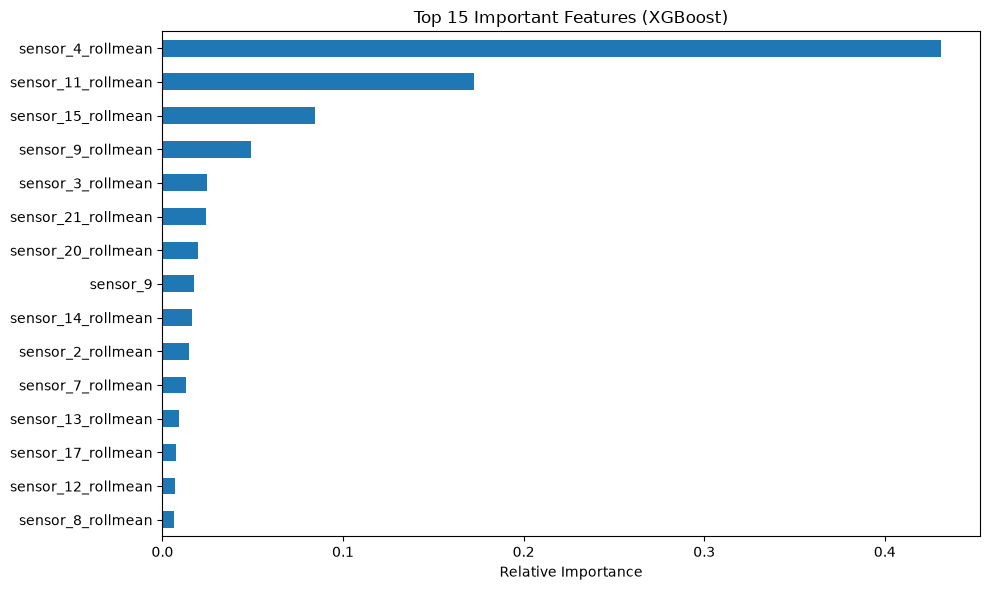

Feature Importance plot saved to: /Users/princegupta/PredictX-AI/docs/xgb_feature_importance.png


In [5]:
# 1. Comparison Table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [20.00, rf_rmse, xgb_rmse],
    "MAE":  [16.12, rf_mae, xgb_mae],
    "R²":   [0.7702, rf_r2, xgb_r2]
})

print("=" * 60)
print("Model Comparison")
print("=" * 60)
display(results)

# 2. Feature Importance Calculation
importance = pd.Series(xgb.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

# 3. Plotting
docs_path = ml_root.parent / "docs"
docs_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10,6))
importance.head(15).plot(kind="barh", color="#1f77b4")
plt.title("Top 15 Important Features (XGBoost)")
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()

# Save the plot
plot_path = docs_path / "xgb_feature_importance.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Feature Importance plot saved to: {plot_path}")